In [1]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [3]:
data = pd.read_csv('data/training_v2.csv')
pd.set_option('display.max_columns', None)
data.head(10)

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_invasive_max,d1_diasbp_invasive_min,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_invasive_max,d1_mbp_invasive_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_invasive_max,d1_sysbp_invasive_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_invasive_max,h1_diasbp_invasive_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_invasive_max,h1_mbp_invasive_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_invasive_max,h1_sysbp_invasive_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_inr_max,d1_inr_min,d1_lactate_max,d1_lactate_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_albumin_max,h1_albumin_min,h1_bilirubin_max,h1_bilirubin_min,h1_bun_max,h1_bun_min,h1_calcium_max,h1_calcium_min,h1_creatinine_max,h1_creatinine_min,h1_glucose_max,h1_glucose_min,h1_hco3_max,h1_hco3_min,h1_hemaglobin_max,h1_hemaglobin_min,h1_hematocrit_max,h1_hematocrit_min,h1_inr_max,h1_inr_min,h1_lactate_max,h1_lactate_min,h1_platelets_max,h1_platelets_min,h1_potassium_max,h1_potassium_min,h1_sodium_max,h1_sodium_min,h1_wbc_max,h1_wbc_min,d1_arterial_pco2_max,d1_arterial_pco2_min,d1_arterial_ph_max,d1_arterial_ph_min,d1_arterial_po2_max,d1_arterial_po2_min,d1_pao2fio2ratio_max,d1_pao2fio2ratio_min,h1_arterial_pco2_max,h1_arterial_pco2_min,h1_arterial_ph_max,h1_arterial_ph_min,h1_arterial_po2_max,h1_arterial_po2_min,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,Floor,Floor,92,admit,CTICU,0.541667,0,73.9,2.3,113.0,502.01,0,0.0,0.4,31.0,2.51,NaN,3.0,6.0,0.0,4.0,168.0,118.0,27.4,0.0,40.0,NaN,NaN,NaN,NaN,36.0,134.0,39.3,NaN,0.0,14.1,46.0,32.0,68.0,37.0,68.0,37.0,119.0,72.0,66.0,40.0,89.0,46.0,89.0,46.0,34.0,10.0,100.0,74.0,122.0,64.0,131.0,73.0,131.0,73.0,39.9,37.2,NaN,NaN,68.0,63.0,68.0,63.0,119.0,108.0,NaN,NaN,86.0,85.0,86.0,85.0,26.0,18.0,100.0,74.0,NaN,NaN,131.0,115.0,131.0,115.0,39.5,37.5,2.3,2.3,0.4,0.4,31.0,30.0,8.5,7.4,2.51,2.23,168.0,109.0,19.0,15.0,8.9,8.9,27.4,27.4,NaN,NaN,1.3,1.0,233.0,233.0,4.0,3.4,136.0,134.0,14.1,14.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,Floor,Floor,90,admit,Med-Surg ICU,0.927778,0,70.2,NaN,1

In [4]:
#vymazeme zaznamy, kde chyba apache 4 skore, ktore pouzijeme ako benchmark
df = data.dropna(subset = ['apache_4a_hospital_death_prob'])

#vymazeme stlpce s viac ako 60% chybajucich hodnot
cols_to_drop = df.columns[df.isna().mean() > 0.6]

#nechame si apache atributy, ktore maju viac ako 60%
keep_cols = ['bilirubin_apache', 'fio2_apache', 'paco2_apache',
             'paco2_for_ph_apache', 'pao2_apache', 'ph_apache']
cols_to_drop = [col for col in cols_to_drop if col not in keep_cols]
df = df.drop(columns = cols_to_drop)

df['apache_2_diagnosis'] = df['apache_2_diagnosis'].astype(str)

df.head(5)

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,Floor,Floor,92,admit,CTICU,0.541667,0,73.9,2.3,113.0,502.01,0,0.0,0.4,31.0,2.51,NaN,3.0,6.0,0.0,4.0,168.0,118.0,27.4,0.0,40.0,NaN,NaN,NaN,NaN,36.0,134.0,39.3,NaN,0.0,14.1,68.0,37.0,68.0,37.0,119.0,72.0,89.0,46.0,89.0,46.0,34.0,10.0,100.0,74.0,131.0,73.0,131.0,73.0,39.9,37.2,68.0,63.0,68.0,63.0,119.0,108.0,86.0,85.0,86.0,85.0,26.0,18.0,100.0,74.0,131.0,115.0,131.0,115.0,39.5,37.5,2.3,2.3,0.4,0.4,31.0,30.0,8.5,7.4,2.51,2.23,168.0,109.0,19.0,15.0,8.9,8.9,27.4,27.4,233.0,233.0,4.0,3.4,136.0,134.0,14.1,14.1,NaN,NaN,0.10,0.05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,Floor,Floor,90,admit,Med-Surg ICU,0.927778,0,70.2,NaN,108.0,203.01,0,0.0,NaN,9.0,0.56,1.0,1.0,3.0,0.0,1.0,145.0,120.0,36.9,0.0,46.0,37.0,37.0,51.0,7.45,33.0,145.0,35.1,NaN,1.0,12.7,95.0,31.0,95.0,31.0,118.0,72.0,120.0,38.0,120.0,38.0,32.0,12.0,100.0,70.0,159.0,67.0,159.0,67.0,36.3,35.1,61.0,48.0,61.0,48.0,114.0,100.0,85.0,57.0,85.0,57.0,31.0,28.0,95.0,70.0,95.0,71.0,95.0,71.0,36.3,36.3,1.6,1.6,0.5,0.5,11.0,9.0,8.6,8.0,0.71,0.56,145.0,128.0,27.0,26.0,11.3,11.1,36.9,36.1,557.0,487.0,4.2,3.8,145.0,145.0,23.3,12.7,145.0,143.0,0.47,0.29,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,Emergency Department,Accident & Emergency,93,admit,Med-Surg ICU,0.000694,0,95.3,NaN,122.0,703.03,0,0.0,NaN,NaN,NaN,NaN,3.0,6.0,0.0,5.0,NaN,102.0,NaN,0.0,68.0,NaN,NaN,NaN,NaN,37.0,NaN,36.7,NaN,0.0,NaN,88.0,48.0,88.0,48.0,96.0,68.0,102.0,68.0,102.0,68.0,21.0,8.0,98.0,91.0,148.0,105.0,148.0,105.0,37.0,36.7,88.0,58.0,88.0,58.0,96.0,78.0,91.0,83.0,91.0,83.0,20.0,16.0,98.0,91.0,148.0,124.0,148.0,124.0,36.7,36.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,Operating Room,Operating Room / Recovery,92,admit,CTICU,0.000694,0,61.7,NaN,

In [5]:
print(len(df))

83766


In [6]:
prob_drop = ['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']
df = df.drop(prob_drop, axis = 1)

In [7]:
#rozdelenie dat na trenovaciu a testovaciu mnozinu
from sklearn.model_selection import train_test_split
data = df.drop('hospital_death', axis = 1)
X, y = data, df['hospital_death']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3,
                                                    stratify = y,
                                                    random_state = 24)
X_train.head(5)

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
90754,125645,114214,30,76.0,27.889646,0,Caucasian,F,163.0,Direct Admit,Accident & Emergency,927,admit,Cardiac ICU,0.000000,0,74.1,3.1,112.0,107.01,0,1.0,NaN,59.0,5.70,NaN,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,NaN,NaN,NaN,NaN,12.0,137.0,36.6,NaN,0.0,7.26,104.0,33.0,104.0,33.0,70.0,54.0,113.0,56.0,113.0,56.0,26.0,12.0,100.0,87.0,210.0,127.0,210.0,127.0,37.3,36.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.1,3.1,NaN,NaN,59.0,46.0,8.1,7.8,5.70,4.60,342.0,132.0,29.0,28.0,10.6,9.8,32.0,29.0,159.0,137.0,4.4,4.3,138.0,137.0,8.11,7.26,176.0,176.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
36778,87225,110178,70,79.0,25.288591,0,Caucasian,F,168.5,NaN,Accident & Emergency,451,admit,Neuro ICU,0.078472,0,71.8,NaN,301.0,403.01,0,0.0,NaN,17.0,0.80,NaN,4.0,6.0,0.0,5.0,107.0,47.0,36.6,0.0,137.0,NaN,NaN,NaN,NaN,26.0,136.0,36.6,3067.2864,0.0,7.40,89.0,34.0,89.0,34.0,94.0,47.0,101.0,50.0,101.0,50.0,23.0,17.0,100.0,89.0,162.0,95.0,162.0,95.0,36.9,36.6,66.0,60.0,66.0,60.0,61.0,57.0,87.0,82.0,87.0,82.0,19.0,19.0,96.0,92.0,153.0,133.0,153.0,133.0,36.7,36.7,NaN,NaN,NaN,NaN,17.0,16.0,9.5,8.7,0.90,0.80,132.0,108.0,33.0,28.0,12.5,12.5,36.6,36.6,148.0,148.0,4.3,3.5,138.0,136.0,7.40,7.40,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic
41543,65763,66497,186,55.0,38.768838,0,Caucasian,F,162.6,Other Hospital,Other Hospital,498,admit,Med-Surg ICU,0.000000,0,102.5,2.5,301.0,404.01,0,0.0,0.9,14.0,0.50,NaN,4.0,6.0,0.0,5.0,190.0,119.0,37.1,0.0,163.0,NaN,NaN,NaN,NaN,15.0,136.0,37.7,2065.1328,0.0,34.14,99.0,70.0,99.0,70.0,116.0,86.0,112.0,88.0,112.0,88.0,23.0,14.0,98.0,87.0,167.0,118.0,167.0,118.0,37.8,37.4,89.0,82.0,89.0,82.0,105.0,98.0,94.0,94.0,94.0,94.0,19.0,16.0,97.0,96.0,158.0,137.0,158.0,137.0,37.4,37.4,2.5,2.5,0.9,0.9,14.0,12.0,8.5,8.3,0.60,0.50,190.0,184.0,30.0,28.0,13.2,12.1,37.8,37.1,257.0,253.0,3.4,3.2,136.0,136.0,34.14,30.24,190.0,190.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic
31351,86753,25396,55,44.0,23.814560,1,Caucasian,F,157.4,Emergency Department,Operating Room / Recovery,376,admit,Med-Surg ICU,0.194444,

In [8]:
#premena gender atributu na binarny 0 - 1
X_train["gender"] = X_train["gender"].replace({"M": 1, "F": 0})
X_test["gender"] = X_test["gender"].replace({"M": 1, "F": 0})

#kategoricke atributy
cat_at = list(X_train.select_dtypes(include = ['object', 'category']).columns)

#kategoricke atributy vedene ako ciselne alebo ako string javiaci sa ako cislo
cat_all = cat_at
print(list(cat_all))

['ethnicity', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_2_diagnosis', 'apache_3j_bodysystem', 'apache_2_bodysystem']


/tmp/ipykernel_99/297393335.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train["gender"] = X_train["gender"].replace({"M": 1, "F": 0})
/tmp/ipykernel_99/297393335.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test["gender"] = X_test["gender"].replace({"M": 1, "F": 0})


In [9]:
#vyskyt unikatnych hodnot kategorickych atributov
print("\nKardinalita kategorických stĺpcov:")

low, mid, high = [], [], []

for col in cat_all:
    print(f"{col}: {X_train[col].nunique()}")
    if X_train[col].nunique() < 20:
        low.append(col)
    elif X_train[col].nunique() < 100:
        mid.append(col)
    elif X_train[col].nunique() >= 100:
        high.append(col)


Kardinalita kategorických stĺpcov:
ethnicity: 6
hospital_admit_source: 15
icu_admit_source: 5
icu_stay_type: 3
icu_type: 8
apache_2_diagnosis: 45
apache_3j_bodysystem: 11
apache_2_bodysystem: 10


In [10]:
#numericke atributy
num_att = list(X_train.select_dtypes(include = ['int64', 'float64']).columns)
num_att = [col for col in num_att if col not in low]
num_att = [col for col in num_att if col not in mid]
print(num_att)

['encounter_id', 'patient_id', 'hospital_id', 'age', 'bmi', 'elective_surgery', 'gender', 'height', 'icu_id', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_sysbp_noninvasive_max'

In [11]:
#doplnenie kategorickych chybajucich hodnot
cat_imp = SimpleImputer(strategy = 'constant', fill_value = 'missing')
cat_imp.fit(X_train[cat_all])

X_train_cat = pd.DataFrame(
    cat_imp.transform(X_train[cat_all]),
    columns = cat_all,
    index = X_train.index
)

#pre testovaciu mnozinu
X_test_cat = pd.DataFrame(
    cat_imp.transform(X_test[cat_all]),
    columns = cat_all,
    index = X_test.index
)

X_train_cat = X_train_cat.astype(str)
X_test_cat = X_test_cat.astype(str)

In [12]:
#doplnenie numerickych chybajucich hodnot
num_imp = SimpleImputer(strategy = 'median')
num_imp.fit(X_train[num_att])

X_train_num = pd.DataFrame(
    num_imp.transform(X_train[num_att]),
    columns = num_att,
    index = X_train.index
)

#pre testovaciu mnozinu
X_test_num = pd.DataFrame(
    num_imp.transform(X_test[num_att]),
    columns = num_att,
    index = X_test.index
)

#spojenie doplnenych atributov
X_train = pd.concat([X_train_num, X_train_cat], axis = 1)
X_test = pd.concat([X_test_num, X_test_cat], axis = 1)

X_train.head(5)

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,gender,height,icu_id,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,apache_2_diagnosis,apache_3j_bodysystem,apache_2_bodysystem
90754,125645.0,114214.0,30.0,76.0,27.889646,0.0,0.0,163.0,927.0,0.000000,0.0,74.1,3.1,107.01,0.0,1.0,0.7,59.0,5.70,0.5,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,40.0,40.0,103.0,7.360,12.0,137.0,36.6,1387.2384,0.0,7.26,104.0,33.0,104.0,33.0,70.0,54.0,113.0,56.0,113.0,56.0,26.0,12.0,100.0,87.0,210.0,127.0,210.0,127.0,37.3,36.6,73.0,62.0,74.0,62.0,90.0,82.0,89.0,78.0,89.0,79.0,21.0,16.0,99.0,96.0,130.0,115.0,130.0,115.0,36.7,36.6,3.1,3.1,0.7,0.6,59.0,46.0,8.1,7.8,5.70,4.60,342.0,132.0,29.0,28.0,10.6,9.8,32.0,29.0,159.0,137.0,4.4,4.3,138.0,137.0,8.11,7.26,176.0,176.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Direct Admit,Accident & Emergency,admit,Cardiac ICU,112.0,Cardiovascular,Cardiovascular
36778,87225.0,110178.0,70.0,79.0,25.288591,0.0,0.0,168.5,451.0,0.078472,0.0,71.8,2.9,403.01,0.0,0.0,0.7,17.0,0.80,0.5,4.0,6.0,0.0,5.0,107.0,47.0,36.6,0.0,137.0,40.0,40.0,103.0,7.360,26.0,136.0,36.6,3067.2864,0.0,7.40,89.0,34.0,89.0,34.0,94.0,47.0,101.0,50.0,101.0,50.0,23.0,17.0,100.0,89.0,162.0,95.0,162.0,95.0,36.9,36.6,66.0,60.0,66.0,60.0,61.0,57.0,87.0,82.0,87.0,82.0,19.0,19.0,96.0,92.0,153.0,133.0,153.0,133.0,36.7,36.7,3.0,2.9,0.7,0.6,17.0,16.0,9.5,8.7,0.90,0.80,132.0,108.0,33.0,28.0,12.5,12.5,36.6,36.6,148.0,148.0,4.3,3.5,138.0,136.0,7.40,7.40,140.0,134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,missing,Accident & Emergency,admit,Neuro ICU,301.0,Neurological,Neurologic
41543,65763.0,66497.0,186.0,55.0,38.768838,0.0,0.0,162.6,498.0,0.000000,0.0,102.5,2.5,404.01,0.0,0.0,0.9,14.0,0.50,0.5,4.0,6.0,0.0,5.0,190.0,119.0,37.1,0.0,163.0,40.0,40.0,103.0,7.360,15.0,136.0,37.7,2065.1328,0.0,34.14,99.0,70.0,99.0,70.0,116.0,86.0,112.0,88.0,112.0,88.0,23.0,14.0,98.0,87.0,167.0,118.0,167.0,118.0,37.8,37.4,89.0,82.0,89.0,82.0,105.0,98.0,94.0,94.0,94.0,94.0,19.0,16.0,97.0,96.0,158.0,137.0,158.0,137.0,37.4,37.4,2.5,2.5,0.9,0.9,14.0,12.0,8.5,8.3,0.60,0.50,190.0,184.0,30.0,28.0,13.2,12.1,37.8,37.1,257.0,253.0,3.4,3.2,136.0,136.0,34.14,30.24,190.0,190.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Other Hospital,Other Hospital,admit,Med-Surg ICU,301.0,Neurological,Neurologic
31351,86753.0,25396.0,55.0,44.0

In [13]:
X_test.head()

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,gender,height,icu_id,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,apache_2_diagnosis,apache_3j_bodysystem,apache_2_bodysystem
20073,7601.0,31473.0,171.0,76.0,28.982732,0.0,1.0,177.0,404.0,0.021528,0.0,90.80,2.9,104.01,0.0,0.0,0.7,33.0,2.04,1.0,4.0,6.0,0.0,5.0,223.0,129.0,43.9,1.0,67.0,38.0,38.0,145.0,7.33,26.0,140.0,36.5,1387.2384,1.0,21.50,75.0,57.0,75.0,57.0,134.0,89.0,84.0,66.0,84.0,66.0,25.0,18.0,99.0,94.0,119.0,86.0,119.0,86.0,39.1,36.5,75.0,63.0,75.0,63.0,134.0,121.0,84.0,68.0,84.0,68.0,21.0,18.0,99.0,94.0,113.0,91.0,113.0,91.0,36.7,36.6,3.0,2.9,0.7,0.6,33.0,20.0,8.0,7.9,2.04,1.14,223.0,133.0,20.0,20.0,16.2,14.6,48.4,43.9,279.0,190.0,4.3,3.0,140.0,140.0,23.00,21.50,191.0,191.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,PACU,Accident & Emergency,admit,CSICU,110.0,Cardiovascular,Cardiovascular
50538,27402.0,49016.0,24.0,63.0,45.262046,0.0,0.0,167.6,523.0,0.109722,0.0,127.14,3.0,403.01,0.0,0.0,0.4,8.0,0.70,0.5,4.0,6.0,0.0,4.0,114.0,50.0,37.3,0.0,136.0,40.0,40.0,103.0,7.36,37.0,140.0,36.1,1023.0624,0.0,8.07,92.0,53.0,92.0,53.0,72.0,49.0,125.0,76.0,125.0,76.0,52.0,14.0,98.0,92.0,183.0,108.0,183.0,108.0,36.6,36.1,68.0,64.0,68.0,64.0,61.0,60.0,98.0,88.0,98.0,88.0,35.0,21.0,98.0,93.0,155.0,123.0,155.0,123.0,36.6,36.6,3.0,3.0,0.4,0.4,8.0,8.0,8.8,8.8,0.70,0.70,114.0,114.0,28.0,28.0,12.0,12.0,37.3,37.3,236.0,236.0,3.6,3.6,140.0,140.0,8.07,8.07,140.0,134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Emergency Department,Accident & Emergency,admit,Med-Surg ICU,301.0,Neurological,Neurologic
43176,74611.0,42129.0,14.0,72.0,30.611605,0.0,1.0,172.7,489.0,2.000694,0.0,91.30,2.9,1207.01,1.0,0.0,0.7,9.0,0.70,0.5,4.0,6.0,1.0,5.0,104.0,106.0,32.2,0.0,58.0,40.0,40.0,103.0,7.36,10.0,137.0,37.1,2237.7600,1.0,11.75,67.0,42.0,66.0,50.0,92.0,60.0,82.0,60.0,77.0,58.0,24.0,10.0,100.0,95.0,134.0,92.0,114.0,82.0,38.2,37.0,62.0,43.0,54.0,51.0,80.0,70.0,80.0,61.0,66.0,58.0,12.0,10.0,100.0,100.0,118.0,92.0,106.0,82.0,38.2,37.8,3.0,2.9,0.7,0.6,9.0,9.0,8.8,7.6,0.70,0.70,215.0,104.0,24.0,23.0,11.6,11.0,35.6,31.2,176.0,172.0,4.6,3.7,139.0,137.0,11.75,11.70,146.0,146.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Operating Room,Operating Room / Recovery,admit,Med-Surg ICU,308.0,Cardiovascular,Undefined diagnoses
33598,28819.0,89955.0,

In [14]:
#pretypovanie kategorickych atributov
#s nizkou kardinalitou - one hot encoding
one_enc = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
one_enc.fit(X_train[low])

X_train_low_enc = pd.DataFrame(
    one_enc.transform(X_train[low]),
    columns = one_enc.get_feature_names_out(low),
    index = X_train.index
)

#pre testovaciu mnozinu
X_test_low_enc = pd.DataFrame(
    one_enc.transform(X_test[low]),
    columns = one_enc.get_feature_names_out(low),
    index = X_test.index
)

In [15]:
#so strednou kardinalitou target encoding
target_enc = TargetEncoder(smooth = "auto")
fold = KFold(n_splits = 5, shuffle = True, random_state = 24)

X_train_mid_enc = pd.DataFrame(index = X_train.index)

for train_idx, val_idx in fold.split(X_train):
  X_tr = X_train.iloc[train_idx]
  X_val = X_train.iloc[val_idx]
  y_tr = y_train.iloc[train_idx]

  target_enc.fit(X_tr[mid], y_tr)
  X_train_mid_folded = target_enc.transform(X_val[mid])
  X_train_mid_enc.loc[X_val.index, mid] = X_train_mid_folded

In [16]:
#opat spojime dataset
X_train_enc = pd.concat(
    [
        X_train[num_att],
        X_train_low_enc,
        X_train_mid_enc
    ],
    axis = 1
)

#pre testovaciu mnozinu
X_test_enc = pd.concat(
    [
        X_test[num_att],
        X_test_low_enc,
        X_test[mid]
    ],
    axis = 1
)

#usporiadame stlpce v testovacej mnozine rovnako ako su v trenovacej mnozine
X_test_enc = X_test_enc[X_train_enc.columns]

X_train_enc.head(5)

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,gender,height,icu_id,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_Renal/Genitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses,apache_2_bodysystem_missing,apache_2_diagnosis
90754,125645.0,114214.0,30.0,76.0,27.889646,0.0,0.0,163.0,927.0,0.000000,0.0,74.1,3.1,107.01,0.0,1.0,0.7,59.0,5.70,0.5,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,40.0,40.0,103.0,7.360,12.0,137.0,36.6,1387.2384,0.0,7.26,104.0,33.0,104.0,33.0,70.0,54.0,113.0,56.0,113.0,56.0,26.0,12.0,100.0,87.0,210.0,127.0,210.0,127.0,37.3,36.6,73.0,62.0,74.0,62.0,90.0,82.

In [17]:
X_test_enc.head()

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,gender,height,icu_id,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_Renal/Genitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses,apache_2_bodysystem_missing,apache_2_diagnosis
20073,7601.0,31473.0,171.0,76.0,28.982732,0.0,1.0,177.0,404.0,0.021528,0.0,90.80,2.9,104.01,0.0,0.0,0.7,33.0,2.04,1.0,4.0,6.0,0.0,5.0,223.0,129.0,43.9,1.0,67.0,38.0,38.0,145.0,7.33,26.0,140.0,36.5,1387.2384,1.0,21.50,75.0,57.0,75.0,57.0,134.0,89.0,84.0,66.0,84.0,66.0,25.0,18.0,99.0,94.0,119.0,86.0,119.0,86.0,39.1,36.5,75.0,63.0,75.0,63.0,134.0,121.0,84

In [18]:
#spearmanova korelacia atributov
num_col = X_train_enc.select_dtypes(include = 'number').columns
pd.set_option('display.max_rows', None)
correl = X_train_enc[num_col].corr(method = 'spearman').abs()
correl.head()

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,gender,height,icu_id,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_Renal/Genitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses,apache_2_bodysystem_missing,apache_2_diagnosis
encounter_id,1.000000,0.005837,0.003627,0.002806,0.001654,0.000025,0.004688,0.008736,0.005647,0.000333,NaN,0.007275,0.004863,0.000450,0.000864,0.008773,0.003231,0.000962,0.001455,0.005220,0.007460,0.012630,0.004606,0.009178,0.001444,0.005628,0.001247,0.003773,0.000235,0.006461,0.006461,0.001065,0.003086,0.005913,0.005865,0.004810,0.007224,0.009051,0.00

In [19]:
upper = correl.where(
    np.triu(np.ones(correl.shape), k=1).astype(bool)
)

threshold = 0.8

high_corr = (
    upper.stack()
         .reset_index()
)

high_corr.columns = ["feature_1", "feature_2", "correlation"]

high_corr = high_corr[
    high_corr["correlation"] > threshold
].sort_values("correlation", ascending=False)

high_corr

,feature_1,feature_2,correlation
15685,apache_3j_bodysystem_missing,apache_2_bodysystem_missing,1.000000
15670,apache_3j_bodysystem_Trauma,apache_2_bodysystem_Trauma,1.000000
15642,apache_3j_bodysystem_Respiratory,apache_2_bodysystem_Respiratory,1.000000
15625,apache_3j_bodysystem_Neurological,apache_2_bodysystem_Neurologic,1.000000
15591,apache_3j_bodysystem_Metabolic,apache_2_bodysystem_Metabolic,1.000000
15572,apache_3j_bodysystem_Hematological,apache_2_bodysystem_Haematologic,1.000000
15511,apache_3j_bodysystem_Gastrointestinal,apache_2_bodysystem_Gastrointestinal,1.000000
4578,paco2_apache,paco2_for_ph_apache,1.000000
8004,d1_sysbp_min,d1_sysbp_noninvasive_min,0.992596
7879,d1_sysbp_max,d1_sysbp_noninvasive_max,0.992562


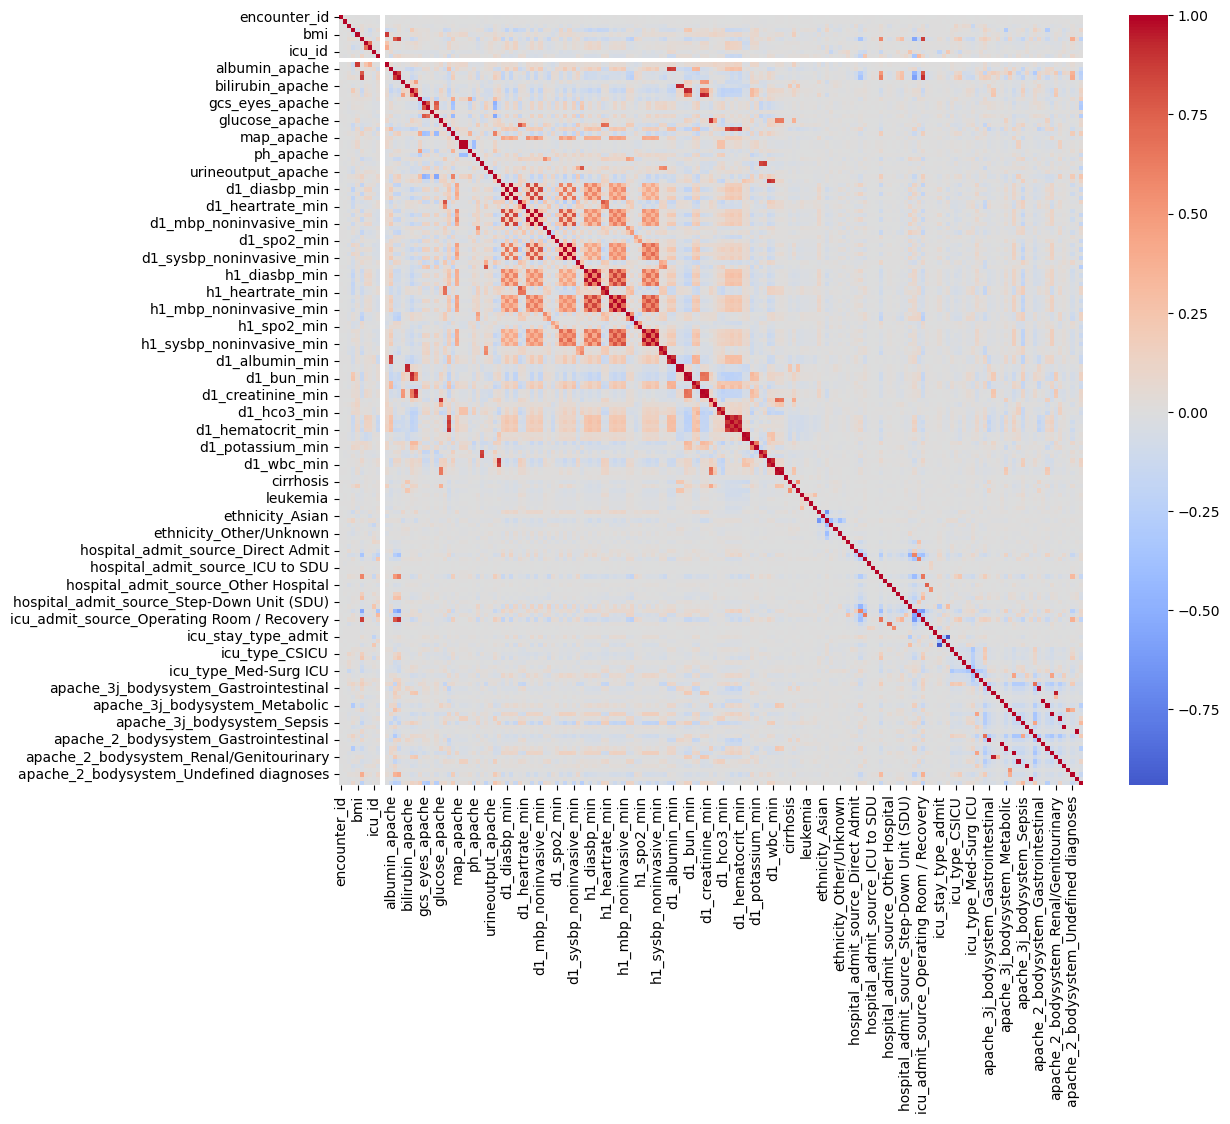

In [20]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    X_train_enc.corr(),
    cmap="coolwarm",
    center=0
)
plt.show()

<Axes: xlabel='gender_label'>

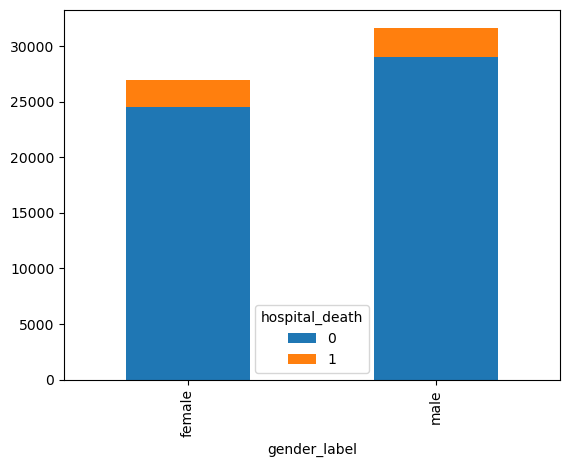

In [21]:
df_train = pd.concat([X_train, y_train], axis=1)

mapping = {
    0: 'female',
    1: 'male'
}

df_train['gender_label'] = df_train['gender'].map(mapping)


pd.crosstab(df_train['gender_label'], df_train['hospital_death']).plot(kind = 'bar', stacked = True)

<Axes: xlabel='gender_label'>

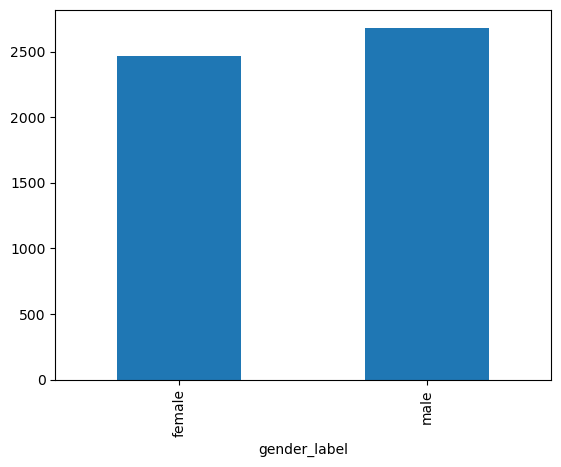

In [22]:
pd.crosstab(df_train['gender_label'], df_train['hospital_death'])[1].plot(kind = 'bar', stacked = True)

<Axes: xlabel='age_bin'>

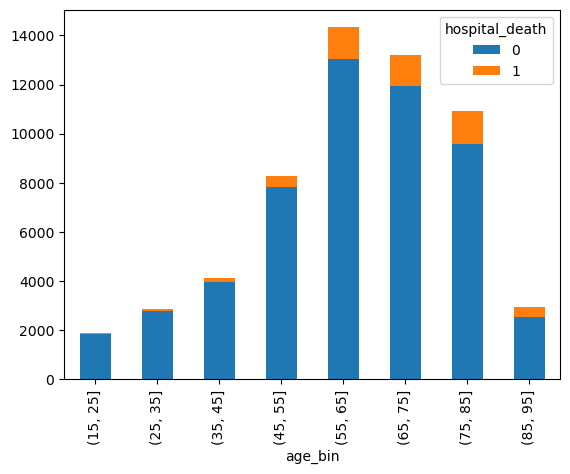

In [23]:
bins = [15, 25, 35, 45, 55, 65, 75, 85, 95]
df_train['age_bin'] = pd.cut(df_train['age'], bins = bins)
pd.crosstab(df_train['age_bin'], df_train['hospital_death']).plot(kind = 'bar', stacked = True)

<Axes: xlabel='age_bin'>

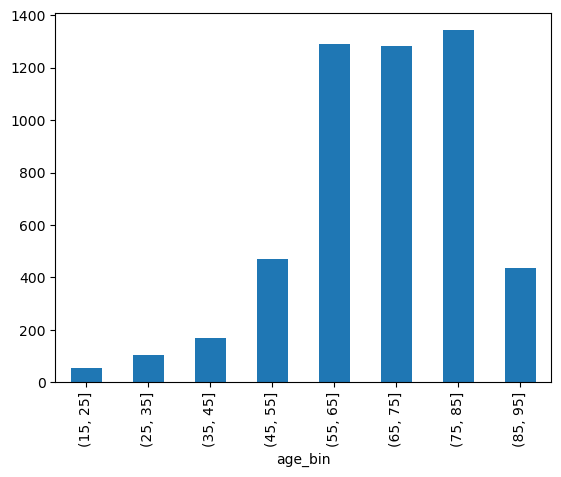

In [24]:
pd.crosstab(df_train['age_bin'], df_train['hospital_death'])[1].plot(kind = 'bar', stacked = True)

/tmp/ipykernel_99/1572043163.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_train.pivot_table(


<Axes: xlabel='age_bin', ylabel='gender_label'>

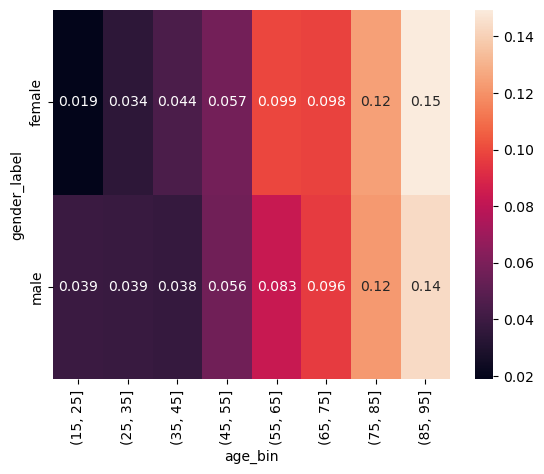

In [25]:
heatmap_data = df_train.pivot_table(
    index = 'gender_label',
    columns = 'age_bin',
    values = 'hospital_death',
    aggfunc = 'mean'
)

sns.heatmap(heatmap_data, annot = True)

<Axes: xlabel='weight_bin'>

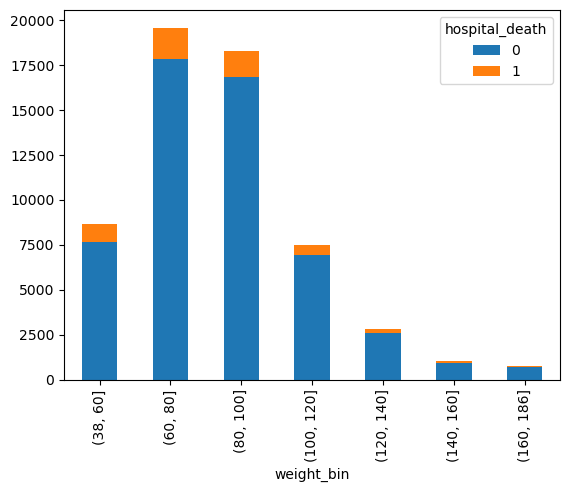

In [26]:
w_bins = [38, 60, 80, 100, 120, 140, 160, 186]
df_train['weight_bin'] = pd.cut(df_train['weight'], bins = w_bins)
pd.crosstab(df_train['weight_bin'], df_train['hospital_death']).plot(kind = 'bar', stacked = True)

<Axes: xlabel='weight_bin'>

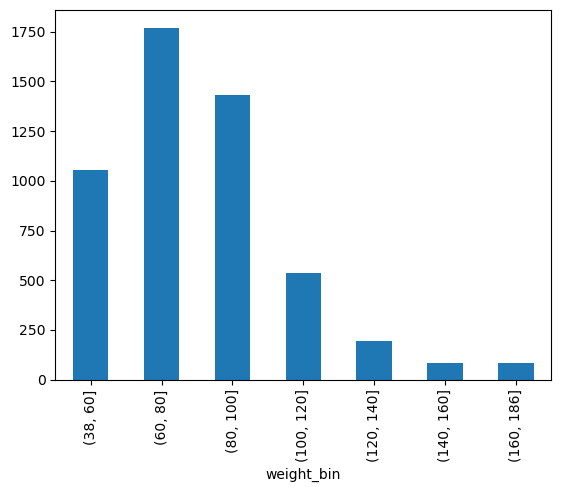

In [27]:
pd.crosstab(df_train['weight_bin'], df_train['hospital_death'])[1].plot(kind = 'bar', stacked = True)

/tmp/ipykernel_99/205862017.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_train.pivot_table(


<Axes: xlabel='weight_bin', ylabel='gender_label'>

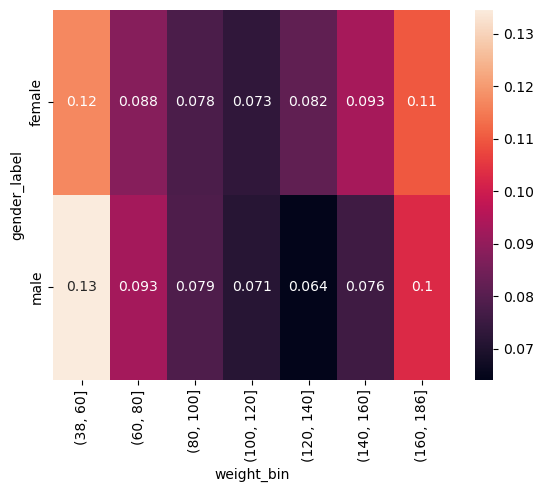

In [28]:
heatmap_data = df_train.pivot_table(
    index = 'gender_label',
    columns = 'weight_bin',
    values = 'hospital_death',
    aggfunc = 'mean'
)

sns.heatmap(heatmap_data, annot = True)

/tmp/ipykernel_99/2246551687.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_train.pivot_table(


<Axes: xlabel='age_bin', ylabel='weight_bin'>

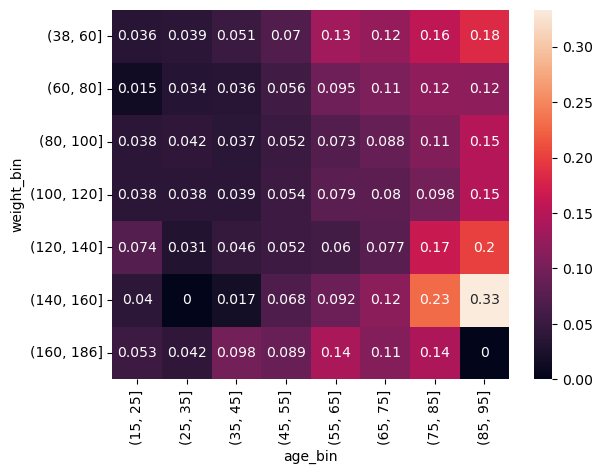

In [29]:
heatmap_data = df_train.pivot_table(
    index = 'weight_bin',
    columns = 'age_bin',
    values = 'hospital_death',
    aggfunc = 'mean'
)

sns.heatmap(heatmap_data, annot = True)

<Axes: xlabel='hrx_bin'>

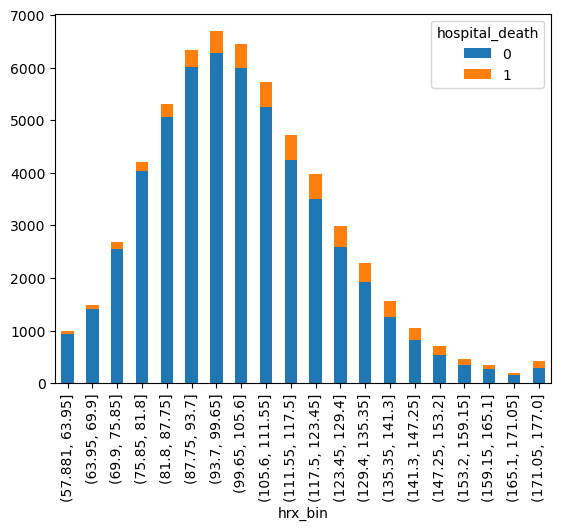

In [30]:
hrx_bins = [58, 80, 100, 120, 140, 160, 177]
df_train['hrx_bin'] = pd.cut(df_train['d1_heartrate_max'], bins = 20)
pd.crosstab(df_train['hrx_bin'], df_train['hospital_death']).plot(kind = 'bar', stacked = True)

<Axes: xlabel='hrx_bin'>

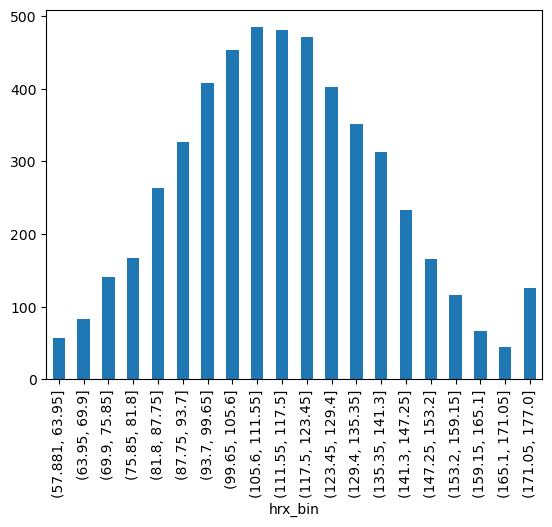

In [31]:
pd.crosstab(df_train['hrx_bin'], df_train['hospital_death'])[1].plot(kind = 'bar', stacked = True)

<Axes: xlabel='hrn_bin'>

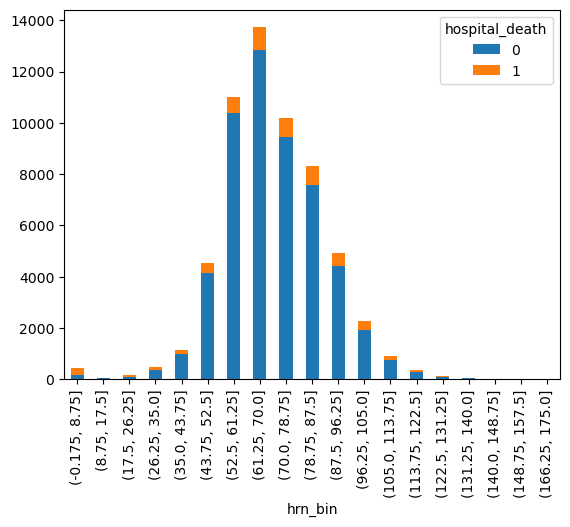

In [32]:
hrn_bins = [0, 60, 80, 100, 120, 140, 160, 175]
df_train['hrn_bin'] = pd.cut(df_train['d1_heartrate_min'], bins = 20)
pd.crosstab(df_train['hrn_bin'], df_train['hospital_death']).plot(kind = 'bar', stacked = True)

<Axes: xlabel='hrn_bin'>

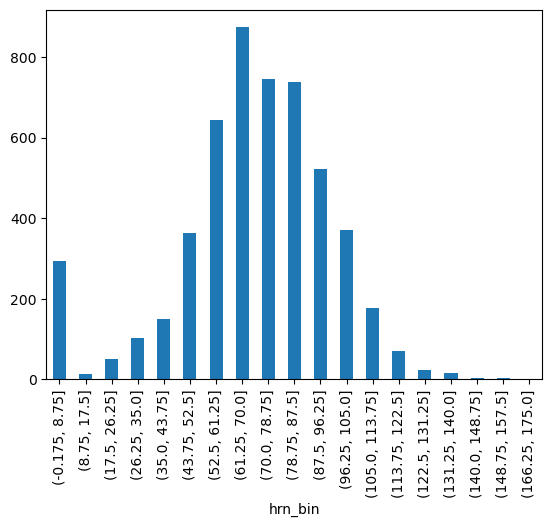

In [33]:
pd.crosstab(df_train['hrn_bin'], df_train['hospital_death'])[1].plot(kind = 'bar', stacked = True)

In [34]:
#spojenie min max atributov do atributu range
cols_min_max = df_train.columns[df_train.columns.str.contains('min|max', case=False)]
min_cols = df_train.columns[df_train.columns.str.endswith('_min')]

for min_col in min_cols:
    base = min_col[:-4]
    max_col = base + '_max'

    if max_col in df_train.columns:
        df_train[base + '_range'] = df_train[max_col] - df_train[min_col]

df_train.head(5)

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,gender,height,icu_id,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,apache_2_diagnosis,apache_3j_bodysystem,apache_2_bodysystem,hospital_death,gender_label,age_bin,weight_bin,hrx_bin,hrn_bin,d1_diasbp_range,d1_diasbp_noninvasive_range,d1_heartrate_range,d1_mbp_range,d1_mbp_noninvasive_range,d1_resprate_range,d1_spo2_range,d1_sysbp_range,d1_sysbp_noninvasive_range,d1_temp_range,h1_diasbp_range,h1_diasbp_noninvasive_range,h1_heartrate_range,h1_mbp_range,h1_mbp_noninvasive_range,h1_resprate_range,h1_spo2_range,h1_sysbp_range,h1_sysbp_noninvasive_range,h1_temp_range,d1_albumin_range,d1_bilirubin_range,d1_bun_range,d1_calcium_range,d1_creatinine_range,d1_glucose_range,d1_hco3_range,d1_hemaglobin_range,d1_hematocrit_range,d1_platelets_range,d1_potassium_range,d1_sodium_range,d1_wbc_range,h1_glucose_range
90754,125645.0,114214.0,30.0,76.0,27.889646,0.0,0.0,163.0,927.0,0.000000,0.0,74.1,3.1,107.01,0.0,1.0,0.7,59.0,5.70,0.5,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,40.0,40.0,103.0,7.360,12.0,137.0,36.6,1387.2384,0.0,7.26,104.0,33.0,104.0,33.0,70.0,54.0,113.0,56.0,113.0,56.0,26.0,12.0,100.0,87.0,210.0,127.0,210.0,127.0,37.3,36.6,73.0,62.0,74.0,62.0,90.0,82.0,89.0,78.0,89.0,79.0,21.0,16.0,99.0,96.0,130.0,115.0,130.0,115.0,36.7,36.6,3.1,3.1,0.7,0.6,59.0,46.0,8.1,7.8,5.70,4.60,342.0,132.0,29.0,28.0,10.6,9.8,32.0,29.0,159.0,137.0,4.4,4.3,138.0,137.0,8.11,7.26,176.0,176.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Direct Admit,Accident & Emergency,admit,Cardiac ICU,112.0,Cardiovascular,Cardiovascular,0,female,"(75, 85]","(60, 80]","(69.9, 75.85]","(52.5, 61.25]",71.0,71.0,16.0,57.0,57.0,14.0,13.0,83.0,83.0,0.7,11.0,12.0,8.0,11.0,10.0,5.0,3.0,15.0,15.0,0.1,0.0,0.1,13.0,0.3,1.10,210.0,1.0,0.8,3.0,22.0,0.1,1.0,0.85,0.0
36778,87225.0,110178.0,70.0,79.0,25.288591,0.0,0.0,168.5,451.0,0.078472,0.0,71.8,2.9,403.01,0.0,0.0,0.7,17.0,0.80,0.5,4.0,6.0,0.0,5.0,107.0,47.0,36.6,0.0,137.0,40.0,40.0,103.0,7.360,26.0,136.0,36.6,3067.2864,0.0,7.40,89.0,34.0,89.0,34.0,94.0,47.0,101.0,50.0,101.0,50.0,23.0,17.0,100.0,89.0,162.0,95.0,162.0,95.0,36.9,36.6,66.0,60.0,66.0,60.0,61.0,57.0,87.0,82.0,87.0,82.0,19.0,19.0,96.0,92.0,153.0,133.0,153.0,133.0,36.7,36.7,3.0,2.9,0.7,0.6,17.0,16.0,9.5,8.7,0.90,0.80,132.0,108.0,33.0,28.0,12.5,12.5,36.6,

<Axes: xlabel='hr_bin'>

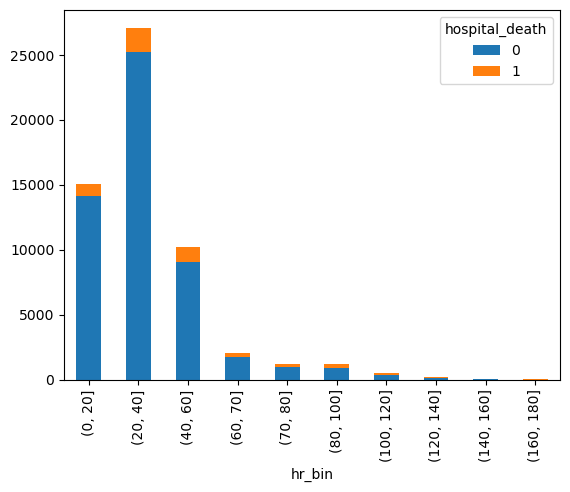

In [39]:
hr_bins = [0, 20, 40, 60, 70, 80, 100, 120, 140, 160, 180]
df_train['hr_bin'] = pd.cut(df_train['d1_heartrate_range'], bins = hr_bins)
pd.crosstab(df_train['hr_bin'], df_train['hospital_death']).plot(kind = 'bar', stacked = True)

In [46]:
df_train.loc[
    df_train['d1_heartrate_range'] < 0,
    ['d1_heartrate_range', 'd1_heartrate_max', 'd1_heartrate_min']
]

,d1_heartrate_range,d1_heartrate_max,d1_heartrate_min
43422,-32.0,58.0,90.0
60072,-35.0,58.0,93.0
67505,-15.0,58.0,73.0
54399,-4.0,58.0,62.0
18989,-10.0,58.0,68.0
42163,-4.0,58.0,62.0
83861,-6.0,58.0,64.0
49407,-18.0,58.0,76.0
49838,-56.0,58.0,114.0
76679,-44.0,58.0,102.0
